# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [34]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [35]:
print(df_hh_income.shape)
print(df_pct_poverty.shape)
print(df_pct_completed_hs.shape)
print(df_share_race_city.shape)
print(df_fatalities.shape)

(29322, 3)
(29329, 3)
(29329, 3)
(29268, 7)
(2535, 14)


In [36]:
print(df_hh_income.columns)
print(df_pct_poverty.columns)
print(df_pct_completed_hs.columns)
print(df_share_race_city.columns)
print(df_fatalities.columns)

Index(['Geographic Area', 'City', 'Median Income'], dtype='object')
Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')
Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')
Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')
Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')


In [37]:
print(df_hh_income.isna().sum())
print(df_pct_poverty.isna().sum())
print(df_pct_completed_hs.isna().sum())
print(df_share_race_city.isna().sum())
print(df_fatalities.isna().sum())

print(df_hh_income.duplicated().sum())
print(df_pct_poverty.duplicated().sum())
print(df_pct_completed_hs.duplicated().sum())
print(df_share_race_city.duplicated().sum())
print(df_fatalities.duplicated().sum())

Geographic Area     0
City                0
Median Income      51
dtype: int64
Geographic Area    0
City               0
poverty_rate       0
dtype: int64
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64
0
0
0
0
0


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [55]:
df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(0)
df_fatalities.age = df_fatalities.age.fillna(0)

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [39]:
df_pct_poverty = df_pct_poverty[df_pct_poverty.poverty_rate != '-']
df_pct_poverty.poverty_rate = pd.to_numeric(df_pct_poverty.poverty_rate)

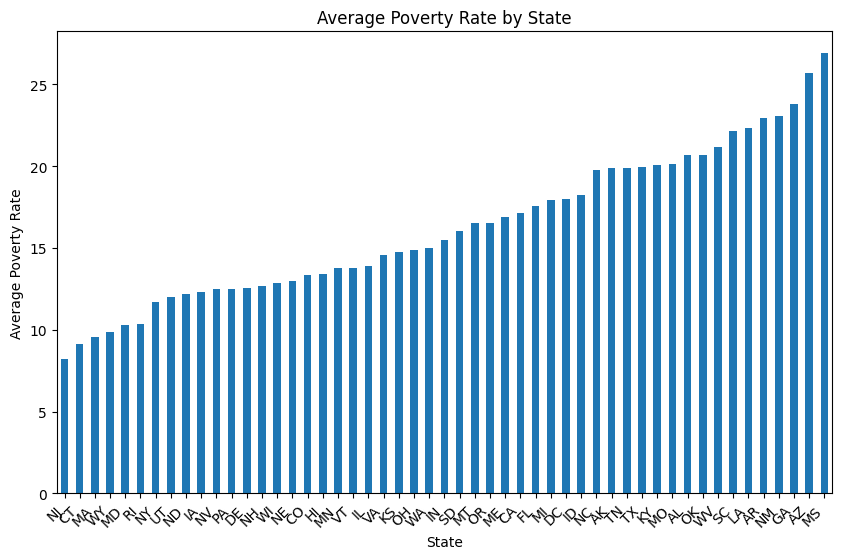

In [40]:
state_poverty_avg = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean()

plt.figure(figsize=(10, 6))
state_poverty_avg.sort_values().plot(kind='bar')
plt.title('Average Poverty Rate by State')
plt.xlabel('State')
plt.ylabel('Average Poverty Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

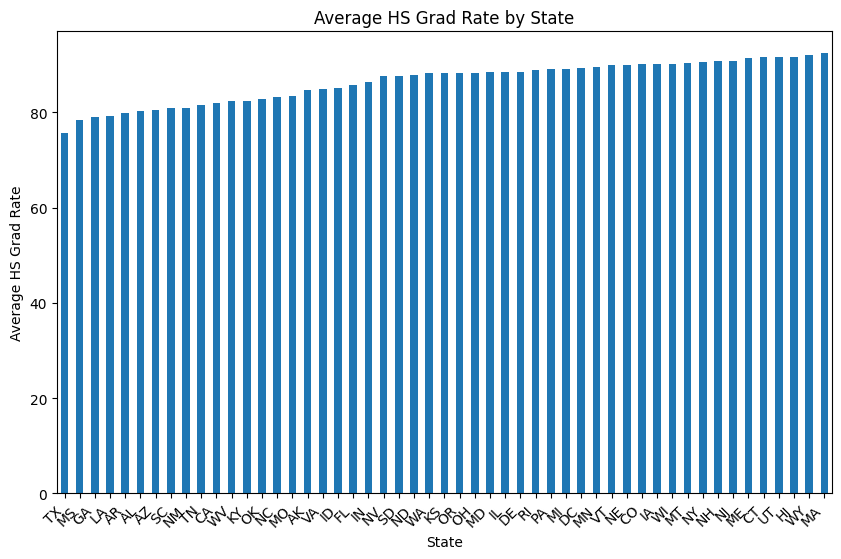

In [49]:
df_pct_completed_hs = df_pct_completed_hs[df_pct_completed_hs.percent_completed_hs != '-']
df_pct_completed_hs.percent_completed_hs = pd.to_numeric(df_pct_completed_hs.percent_completed_hs)

state_grade_avg = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean()

plt.figure(figsize=(10, 6))
state_grade_avg.sort_values().plot(kind='bar')
plt.title('Average HS Grad Rate by State')
plt.xlabel('State')
plt.ylabel('Average HS Grad Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

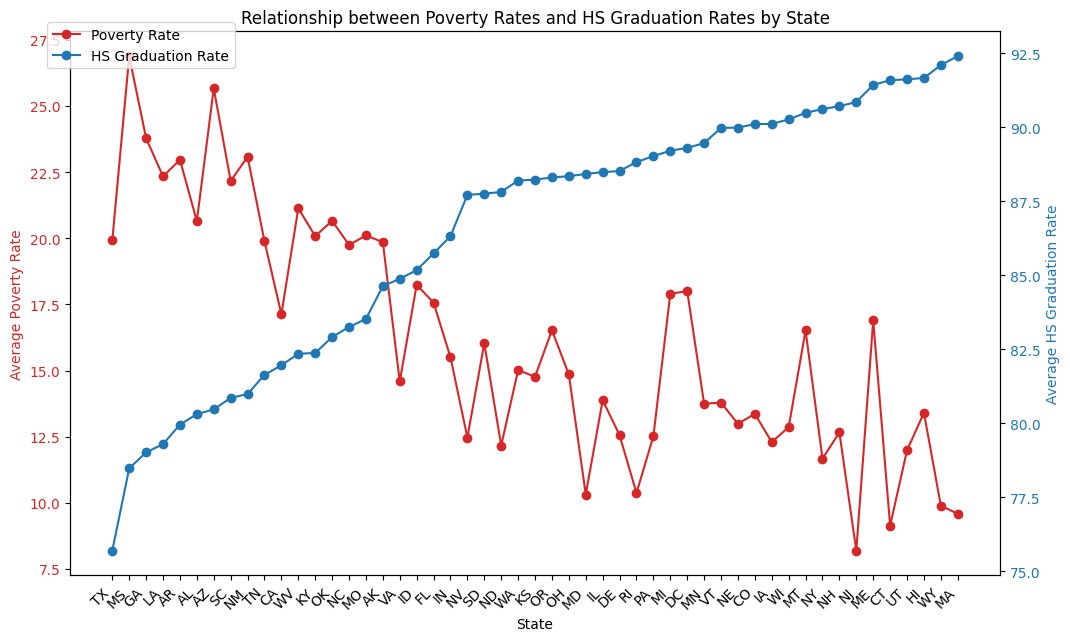

In [51]:
state_grade_avg_sorted = state_grade_avg.sort_values()

# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot the average poverty rate on the left y-axis using the sorted index
ax1.set_xlabel('State')
ax1.set_ylabel('Average Poverty Rate', color='tab:red')
ax1.plot(state_poverty_avg[state_grade_avg_sorted.index], color='tab:red', marker='o', label='Poverty Rate')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Average HS Graduation Rate', color='tab:blue')
ax2.plot(state_grade_avg_sorted, color='tab:blue', marker='o', label='HS Graduation Rate')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add a title
plt.title('Relationship between Poverty Rates and HS Graduation Rates by State')

# Align the x-axis labels for better readability
fig.autofmt_xdate(rotation=45)

# Display the legend
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

# Show the plot
plt.show()


#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

/opt/homebrew/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'marker'
  cset = contour_func(


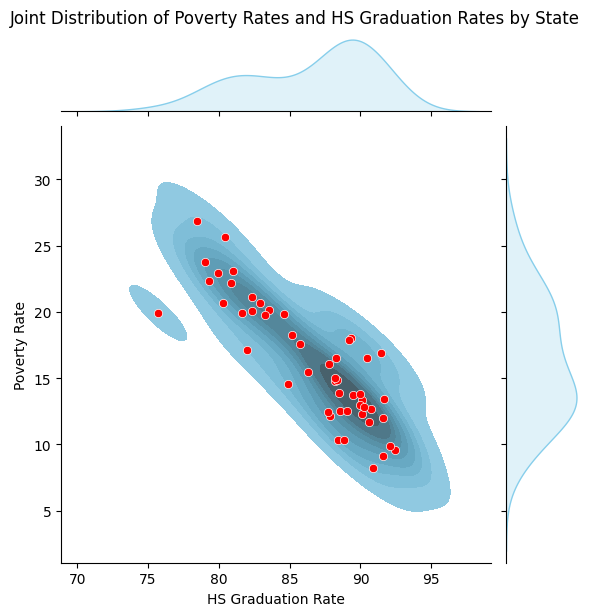

In [53]:
df_combined = pd.DataFrame({
    'Poverty Rate': state_poverty_avg,
    'HS Graduation Rate': state_grade_avg
})

# Create a Seaborn jointplot with KDE and scatter plot
sns.jointplot(data=df_combined, x='HS Graduation Rate', y='Poverty Rate', kind='kde', fill=True, color="skyblue", marker='o')

# Overlay the scatter plot on the jointplot
sns.scatterplot(data=df_combined, x='HS Graduation Rate', y='Poverty Rate', color='red')

# Set the title for the plot
plt.suptitle('Joint Distribution of Poverty Rates and HS Graduation Rates by State', y=1.02)

# Show the plot
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

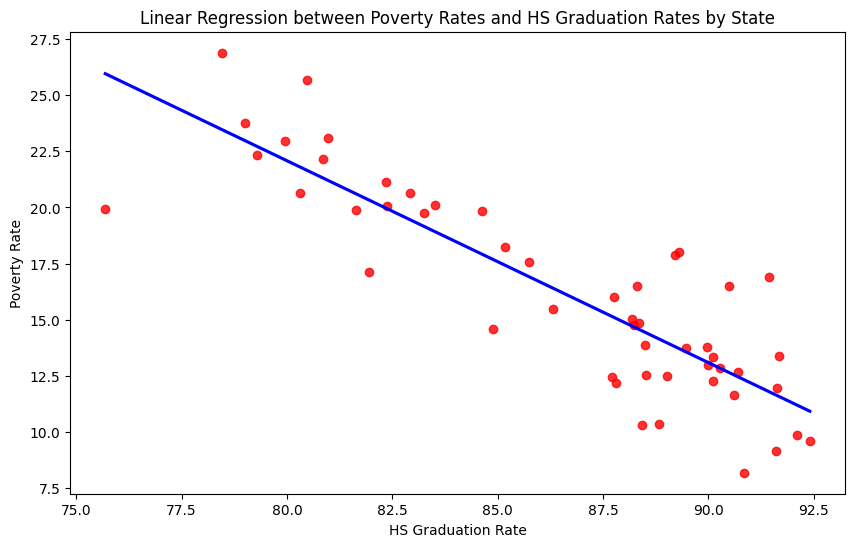

In [54]:
df_combined = pd.DataFrame({
    'Poverty Rate': state_poverty_avg,
    'HS Graduation Rate': state_grade_avg
})

plt.figure(figsize=(10, 6))
sns.regplot(data=df_combined, x='HS Graduation Rate', y='Poverty Rate', ci=None, scatter_kws={'color':'red'}, line_kws={'color':'blue'})

# Set the title for the plot
plt.title('Linear Regression between Poverty Rates and HS Graduation Rates by State')

# Show the plot
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [77]:
df_share_race_city = df_share_race_city[df_share_race_city.share_white != '(X)']
df_share_race_city.share_white = pd.to_numeric(df_share_race_city.share_white)
df_share_race_city.share_black = pd.to_numeric(df_share_race_city.share_black)
df_share_race_city.share_native_american = pd.to_numeric(df_share_race_city.share_native_american)
df_share_race_city.share_asian = pd.to_numeric(df_share_race_city.share_asian)
df_share_race_city.share_hispanic = pd.to_numeric(df_share_race_city.share_hispanic)

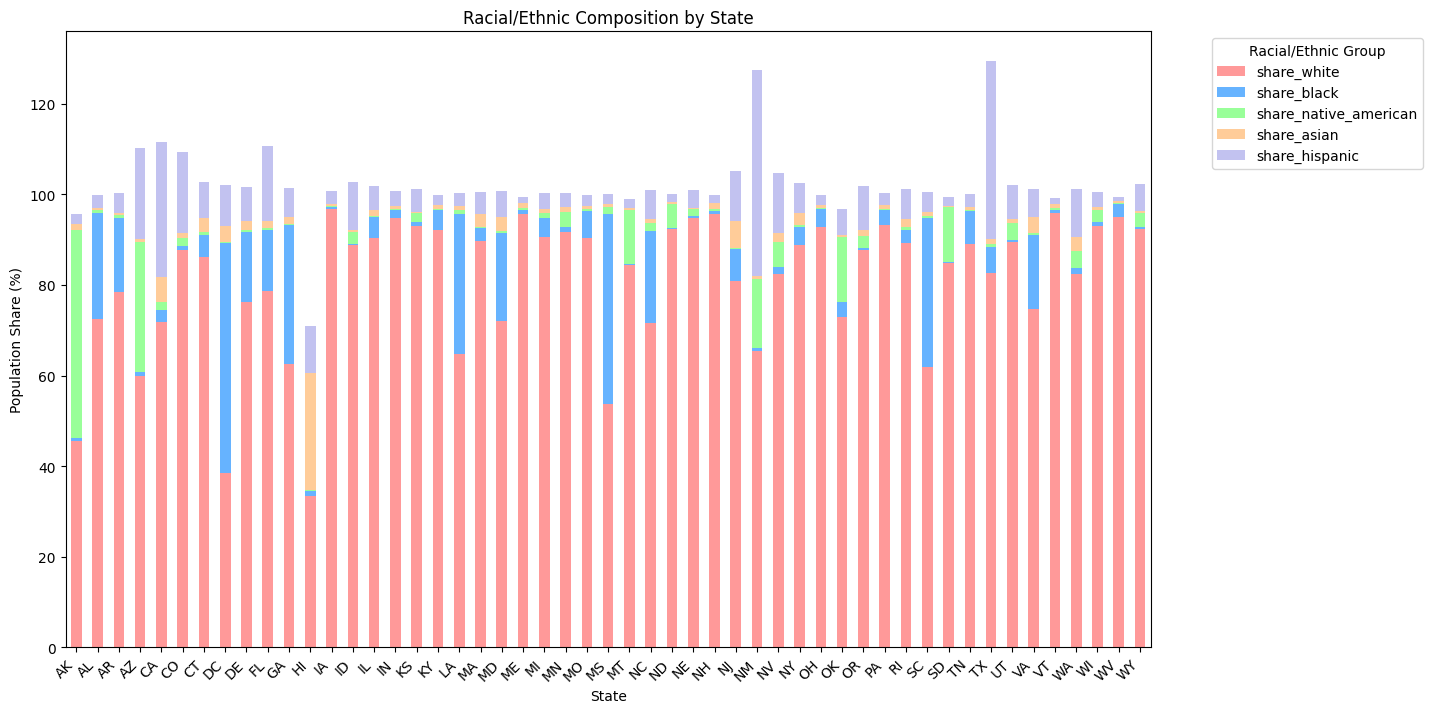

In [81]:
numeric_columns = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
state_race_avg = df_share_race_city.groupby('Geographic area')[numeric_columns].mean()

state_race_avg.plot(kind='bar', stacked=True, figsize=(14, 8),
                    color=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])

plt.title('Racial/Ethnic Composition by State')
plt.xlabel('State')
plt.ylabel('Population Share (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Racial/Ethnic Group", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

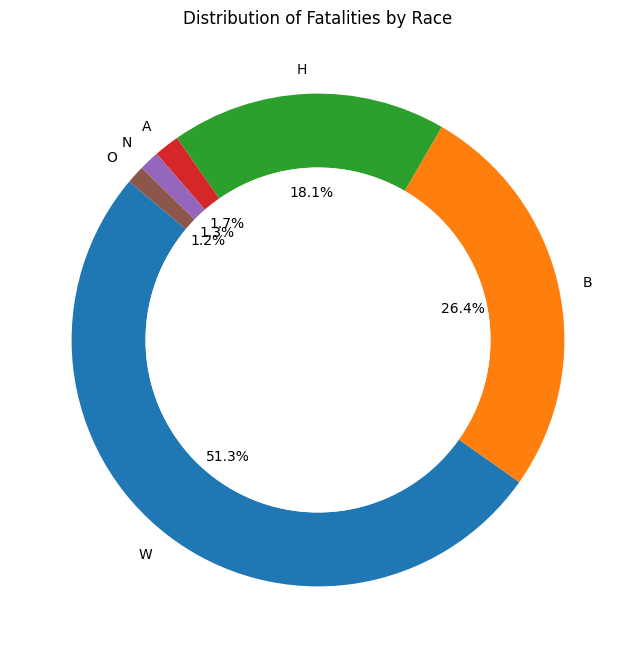

In [85]:
race_counts = df_fatalities['race'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(race_counts, labels=race_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops={'width': 0.3})

# Draw a circle at the center to create a donut shape
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

# Add a title
plt.title('Distribution of Fatalities by Race')

# Display the donut chart
plt.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

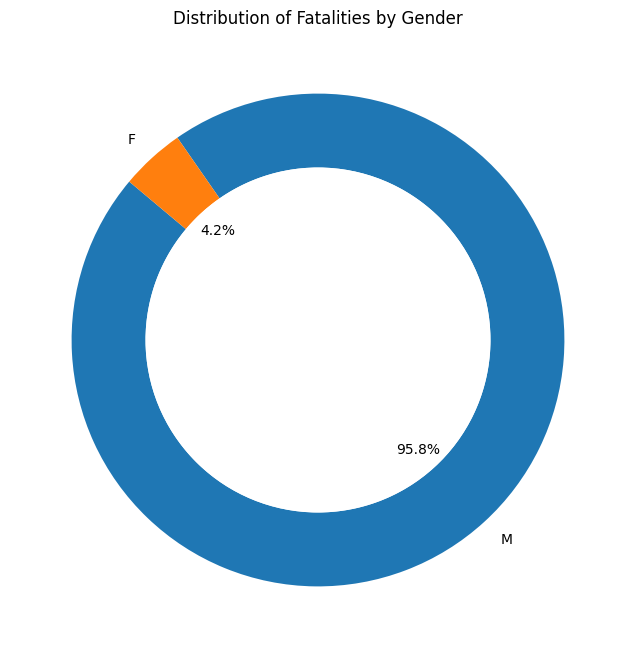

In [91]:
gen_count = df_fatalities.gender.value_counts()
plt.figure(figsize=(8, 8))
plt.pie(gen_count, labels=gen_count.index, autopct='%1.1f%%', startangle=140, wedgeprops={'width': 0.3})

# Draw a circle at the center to create a donut shape
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

# Add a title
plt.title('Distribution of Fatalities by Gender')

# Display the donut chart
plt.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [93]:
men = df_fatalities[df_fatalities.gender == 'M']
female = df_fatalities[df_fatalities.gender == 'F']

In [96]:
men.manner_of_death.value_counts()

manner_of_death
shot                2261
shot and Tasered     167
Name: count, dtype: int64

In [97]:
female.manner_of_death.value_counts()

manner_of_death
shot                102
shot and Tasered      5
Name: count, dtype: int64

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

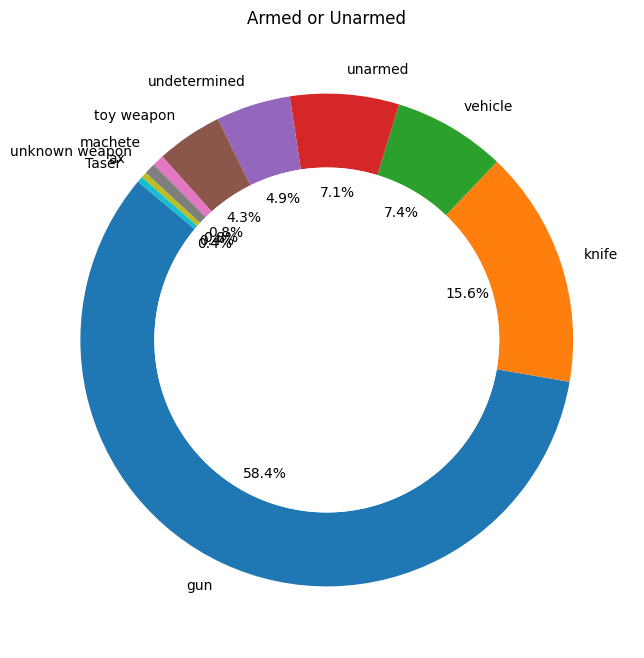

In [102]:
armed_counts = df_fatalities.armed.value_counts()[:10]
plt.figure(figsize=(8, 8))
plt.pie(armed_counts, labels=armed_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops={'width': 0.3})

# Draw a circle at the center to create a donut shape
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

# Add a title
plt.title('Armed or Unarmed')

# Display the donut chart
plt.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [107]:
len(df_fatalities[df_fatalities.age < 25])/len(df_fatalities)*100

20.78895463510848

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

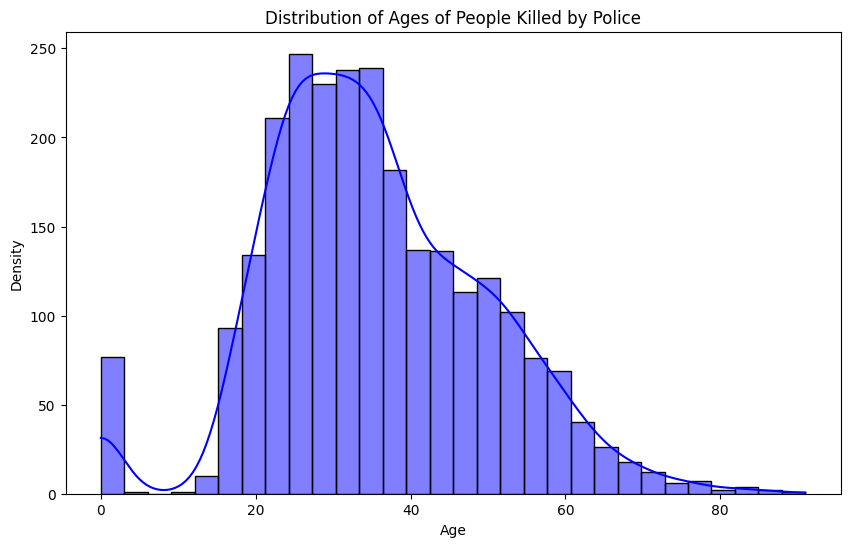

In [108]:
plt.figure(figsize=(10, 6))
# Create the histogram and KDE plot
sns.histplot(df_fatalities['age'], kde=True, bins=30, color='blue')

# Add a title and labels
plt.title('Distribution of Ages of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Density')

# Display the plot
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

<Figure size 1200x800 with 0 Axes>

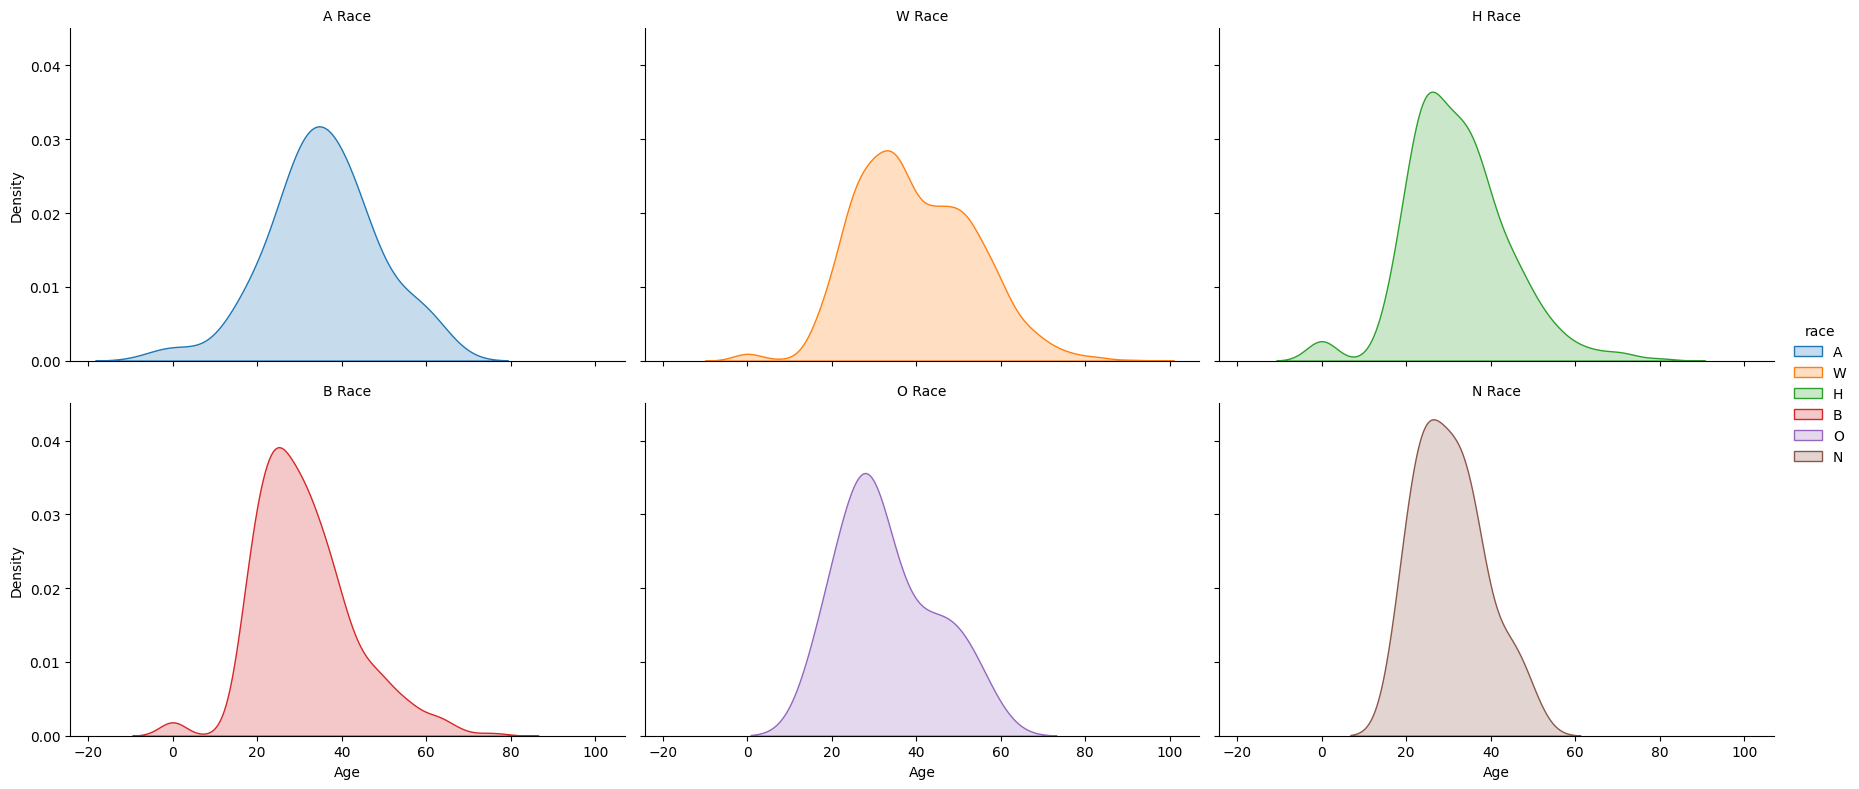

In [111]:
plt.figure(figsize=(12, 8))

# Create a FacetGrid for KDE plots separated by race
g = sns.FacetGrid(df_fatalities, hue="race", col="race", col_wrap=3, height=4, aspect=1.5)

# Map the KDE plot to the grid
g.map(sns.kdeplot, "age", fill=True)

# Add titles and labels
g.set_axis_labels("Age", "Density")
g.set_titles("{col_name} Race")
g.add_legend()

# Display the plot
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

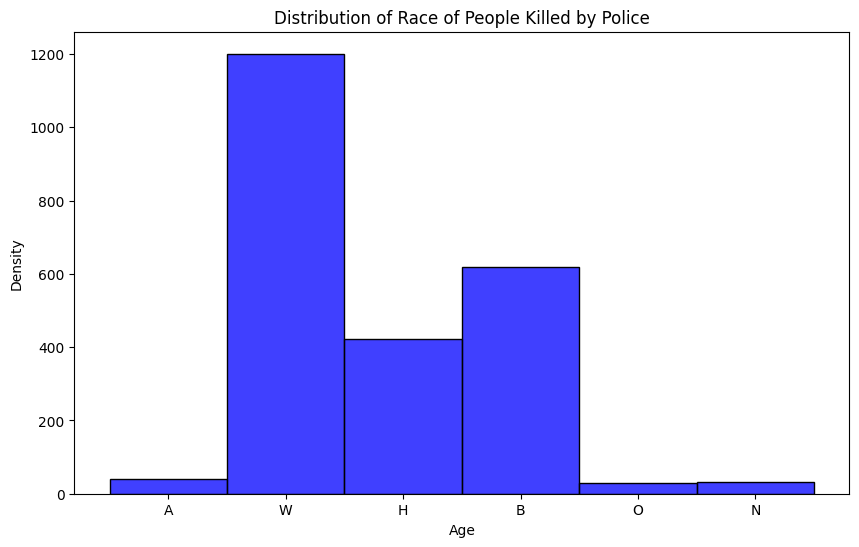

In [110]:
plt.figure(figsize=(10, 6))
# Create the histogram and KDE plot
sns.histplot(df_fatalities['race'], bins=30, color='blue')

# Add a title and labels
plt.title('Distribution of Race of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Density')

# Display the plot
plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [115]:
len(df_fatalities[df_fatalities.signs_of_mental_illness == True])/len(df_fatalities)*100

24.970414201183434

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

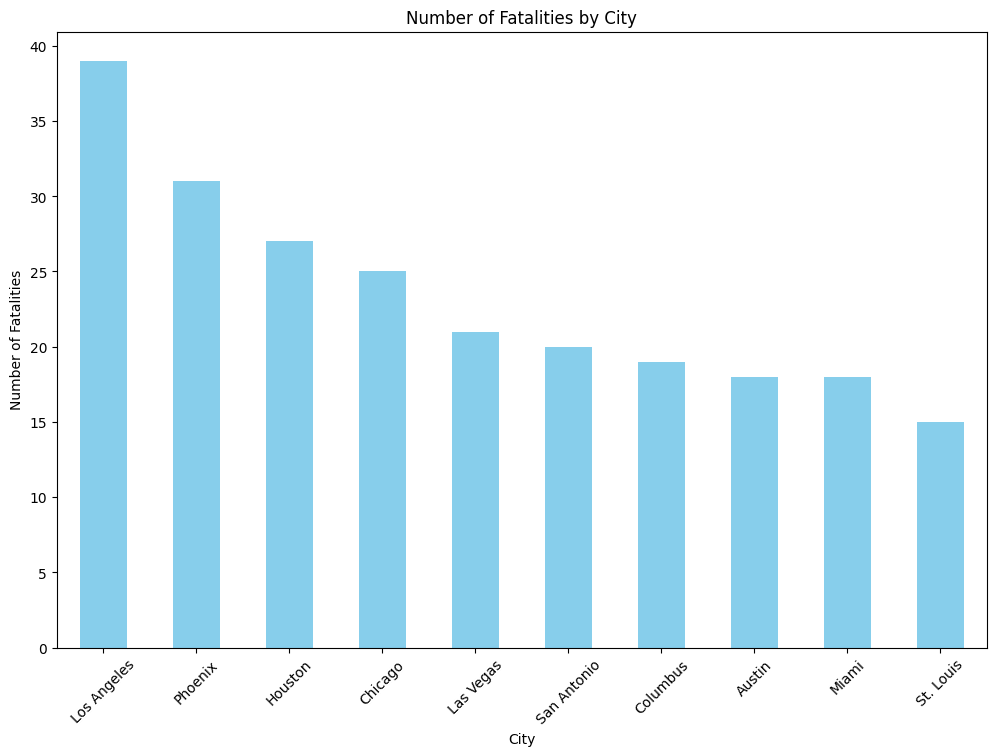

In [125]:
cities = df_fatalities.city.value_counts()[:10]
plt.figure(figsize=(12, 8))

cities.plot(kind='bar', color='skyblue')
plt.title('Number of Fatalities by City')
plt.xlabel('City')
plt.ylabel('Number of Fatalities')

plt.xticks(rotation=45)

# Display the plot
plt.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [153]:
top_10_cities = df_fatalities.city.value_counts().head(10).index
df_top_10_cities = df_fatalities[df_fatalities.city.isin(top_10_cities)]
racial_share_in_killings = df_top_10_cities.groupby('city')['race'].value_counts(normalize=True).unstack().fillna(0)
print("Racial share in killings:")
print(racial_share_in_killings)

Racial share in killings:
race           A    B    H    N    O    W
city                                     
Austin      0.00 0.17 0.11 0.00 0.00 0.72
Chicago     0.00 0.88 0.04 0.00 0.00 0.08
Columbus    0.00 0.61 0.00 0.00 0.06 0.33
Houston     0.04 0.58 0.23 0.04 0.00 0.12
Las Vegas   0.00 0.18 0.29 0.00 0.00 0.53
Los Angeles 0.03 0.28 0.53 0.00 0.00 0.17
Miami       0.00 0.47 0.35 0.00 0.00 0.18
Phoenix     0.00 0.07 0.39 0.11 0.00 0.43
San Antonio 0.00 0.17 0.67 0.00 0.00 0.17
St. Louis   0.00 0.79 0.00 0.00 0.00 0.21


# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [155]:
state_killings = df_fatalities['state'].value_counts().reset_index()
state_killings.columns = ['state', 'killings']

# Step 2: Create a choropleth map
fig = px.choropleth(
    state_killings,
    locations='state',  # Column with state abbreviations
    locationmode='USA-states',  # Specifies that the locations are USA state abbreviations
    color='killings',  # The data to be color-coded
    color_continuous_scale='Reds',  # Color scale
    scope='usa',  # Focus on the USA
    labels={'killings': 'Police Killings'},  # Label for color bar
    title='Police Killings by US State'
)

# Show the map
fig.show(renderer='browser')

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [159]:
df_fatalities.date = pd.to_datetime(df_fatalities.date)
# Aggregate the number of police killings by year
killings_per_year = df_fatalities['date'].dt.year.value_counts().sort_index()

# Aggregate the number of police killings by month and year
killings_per_month = df_fatalities['date'].dt.to_period('M').value_counts().sort_index()


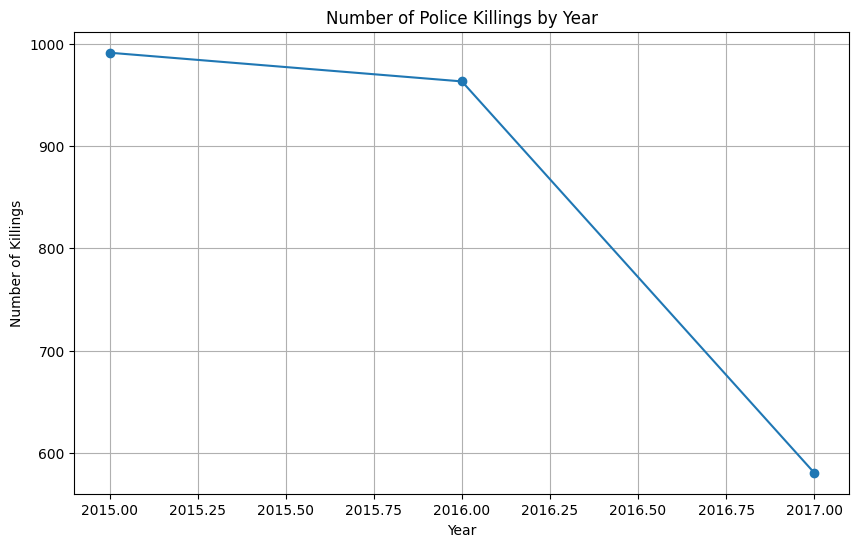

In [161]:
plt.figure(figsize=(10, 6))
killings_per_year.plot(kind='line', marker='o')
plt.title('Number of Police Killings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Killings')
plt.grid(True)
plt.show()


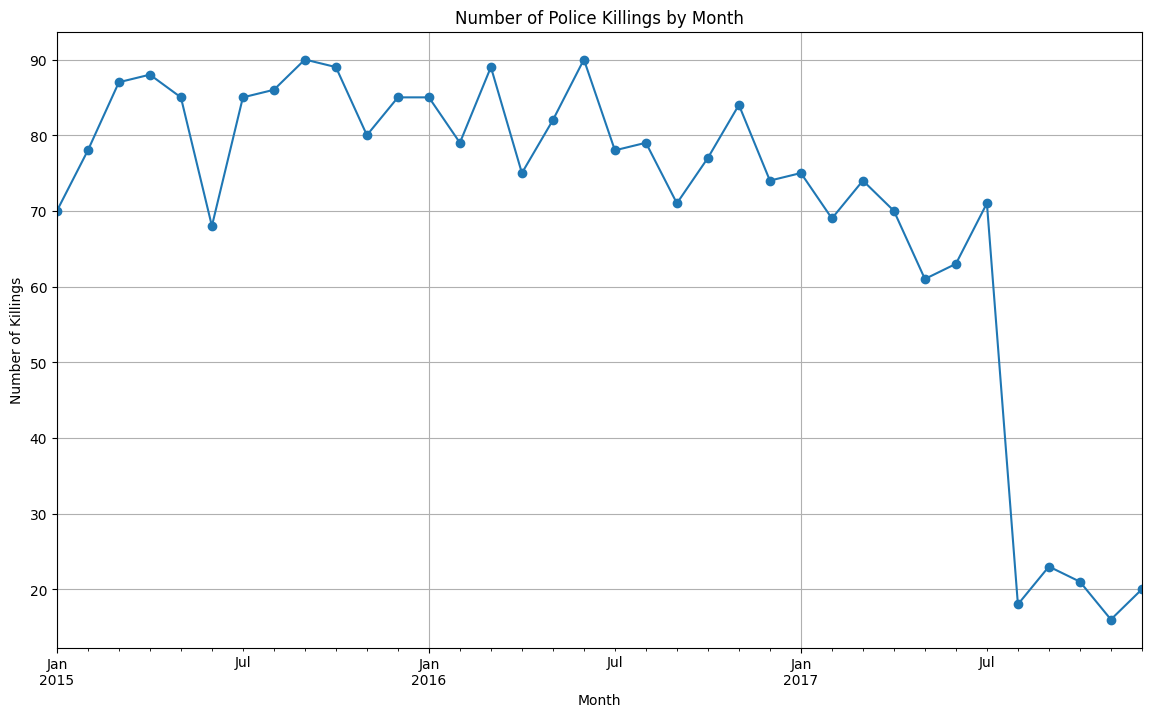

In [162]:
plt.figure(figsize=(14, 8))
killings_per_month.plot(kind='line', marker='o')
plt.title('Number of Police Killings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Killings')
plt.grid(True)
plt.show()
